# Import Libraries 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn



# Set random seed

In [2]:
torch.manual_seed(42)
np.random.seed(42)

# Generate synthetic data

In [3]:

X = torch.randn(1000, 10)
y = torch.randn(1000, 1)

# Network with Sigmoid activations

In [4]:

class SigmoidNet(nn.Module):
    def __init__(self, depth=10):
        super().__init__()
        layers = []
        in_dim = 10
        for i in range(depth):
            layers.append(nn.Linear(in_dim, 64))
            layers.append(nn.Sigmoid())
            in_dim = 64
        layers.append(nn.Linear(64, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# Network with ReLU activations

In [5]:

class ReLUNet(nn.Module):
    def __init__(self, depth=10):
        super().__init__()
        layers = []
        in_dim = 10
        for i in range(depth):
            layers.append(nn.Linear(in_dim, 64))
            layers.append(nn.ReLU())
            in_dim = 64
        layers.append(nn.Linear(64, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


# Function to measure gradient magnitudes

In [6]:

def measure_gradients(model, X, y):
    y_pred = model(X)
    loss = nn.MSELoss()(y_pred, y)
    loss.backward()
    
    gradient_norms = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_norm = param.grad.data.norm().item()
            gradient_norms.append(grad_norm)
    
    return gradient_norms

# Train and measure

In [7]:

depths = [2, 5, 10, 20, 50]
sigmoid_grads = []
relu_grads = []

for depth in depths:
    # Sigmoid network
    sigmoid_net = SigmoidNet(depth=depth)
    grads = measure_gradients(sigmoid_net, X, y)
    avg_grad = np.mean(grads) if grads else 0
    sigmoid_grads.append(avg_grad)
    
    # ReLU network
    relu_net = ReLUNet(depth=depth)
    grads = measure_gradients(relu_net, X, y)
    avg_grad = np.mean(grads) if grads else 0
    relu_grads.append(avg_grad)

# Plot

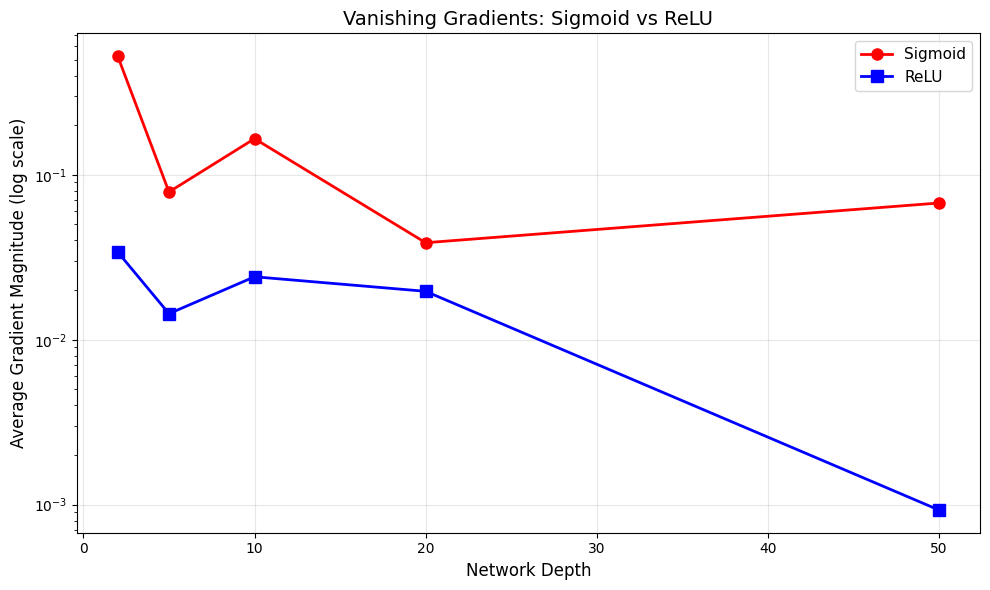

In [8]:


plt.figure(figsize=(10, 6))
plt.semilogy(depths, sigmoid_grads, 'o-', linewidth=2, label='Sigmoid', color='red', markersize=8)
plt.semilogy(depths, relu_grads, 's-', linewidth=2, label='ReLU', color='blue', markersize=8)
plt.xlabel('Network Depth', fontsize=12)
plt.ylabel('Average Gradient Magnitude (log scale)', fontsize=12)
plt.title('Vanishing Gradients: Sigmoid vs ReLU', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [9]:



print("Sigmoid networks:")
for depth, grad in zip(depths, sigmoid_grads):
    print(f"  Depth {depth:2d}: {grad:.2e}")

print("\nReLU networks:")
for depth, grad in zip(depths, relu_grads):
    print(f"  Depth {depth:2d}: {grad:.2e}")


Sigmoid networks:
  Depth  2: 5.25e-01
  Depth  5: 7.87e-02
  Depth 10: 1.66e-01
  Depth 20: 3.87e-02
  Depth 50: 6.75e-02

ReLU networks:
  Depth  2: 3.41e-02
  Depth  5: 1.44e-02
  Depth 10: 2.41e-02
  Depth 20: 1.97e-02
  Depth 50: 9.28e-04
